<a href="https://colab.research.google.com/github/anshulkr69/learning-to-make-machine-learn/blob/main/12-Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression
there are two ways of explaining it:


1.   Geometric
2.   Probability

The geometric part is everywhere online, we will be dealing with the 2nd way in this.



## Requirement
The data should be linearly seperable.

## Perceptron Trick
Watch video 70

What we basically do is:
1. Draw a random line on the plane.
2. Take a random data point and test it against the line.
3. If the point is on the right side of the line we leave the line as it is.
4. If the point is on the opp. side of the line, it pulls the line towards itself.

### Code

In [ ]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [ ]:
import matplotlib.pyplot as plt

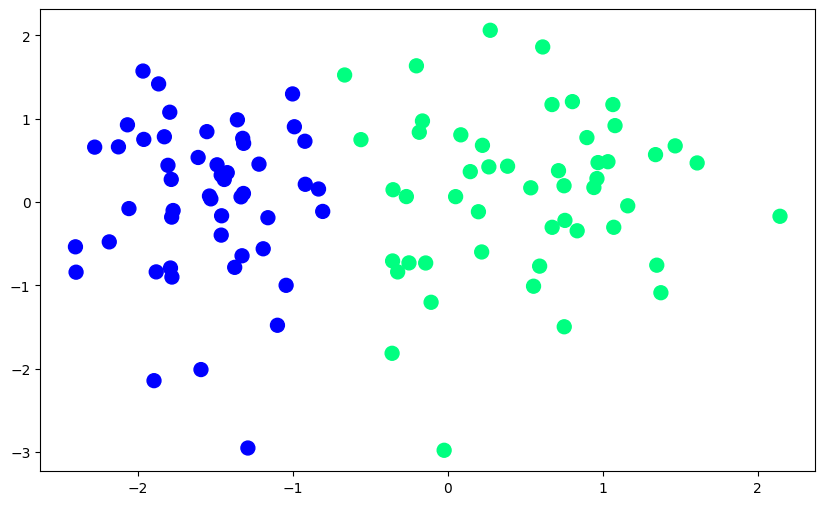

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [ ]:
def perceptron(X,y,lr,epoch):

  X = np.insert(X,0,1,axis = 1)
  weights = np.ones(X.shape[1])


  for i in range(epoch):
    r = np.random.randint(0,X.shape[0])
    y_pred = step(np.dot(X[r], weights))
    weights = weights + lr*(y[r] - y_pred)*X[r]

  return weights[0], weights[1:]

In [ ]:
def step(n):
  return 1 if n>0 else 0

In [ ]:
intercept_,coef_ = perceptron(X,y,0.15,250)

In [ ]:
print(coef_)
print(intercept_)

[1.46899076 0.07376252]
0.8499999999999999


In [ ]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [ ]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

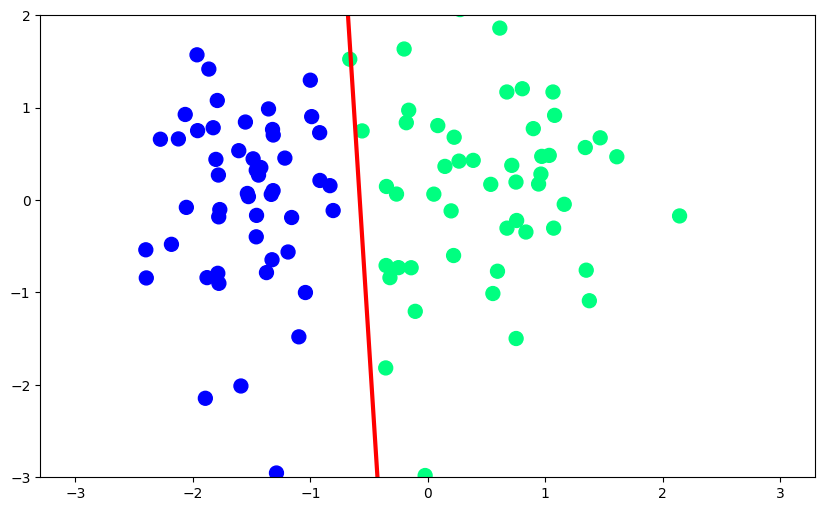

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

There is a major problem with this. The problem is show below:

### THE PROBLEM

As we increase the seperation between the classes, we see that this model doesn't perform as the sklearn LR model does.

In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [2]:
import matplotlib.pyplot as plt

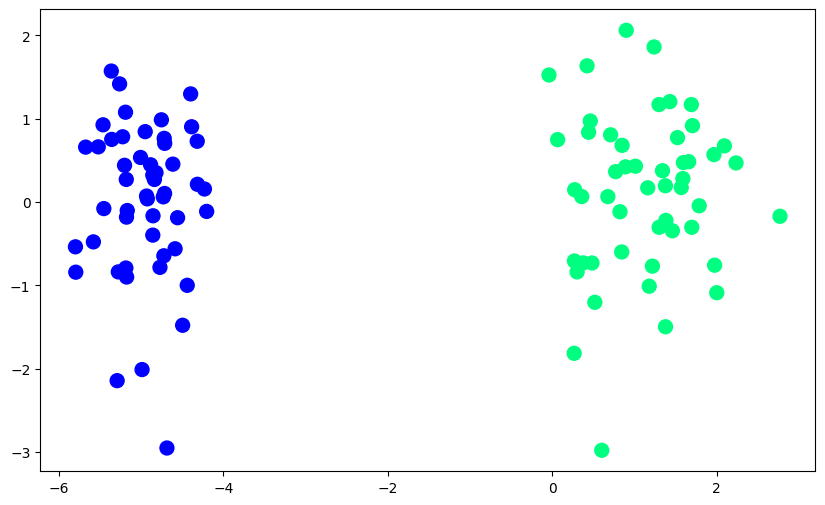

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [4]:
def perceptron(X,y,lr,epoch):

  X = np.insert(X,0,1,axis = 1)
  weights = np.ones(X.shape[1])


  for i in range(epoch):
    r = np.random.randint(0,X.shape[0])
    y_pred = step(np.dot(X[r], weights))
    weights = weights + lr*(y[r] - y_pred)*X[r]

  return weights[0], weights[1:]

In [5]:
def step(n):
  return 1 if n>0 else 0

In [6]:
intercept_,coef_ = perceptron(X,y,0.15,250)

In [7]:
print(coef_)
print(intercept_)

[1.13024308 0.28036544]
1.2999999999999998


In [16]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [15]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

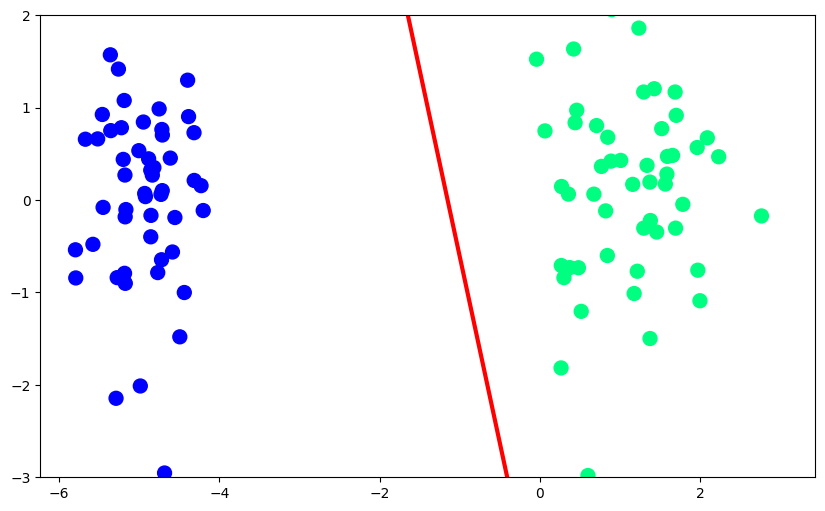

In [10]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

Now let's test the sklearn model.

In [17]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(X, y)
m1 = -(LR.coef_[0][0]/LR.coef_[0][1])
b1 = -(LR.intercept_/LR.coef_[0][1])
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

(-3.0, 2.0)

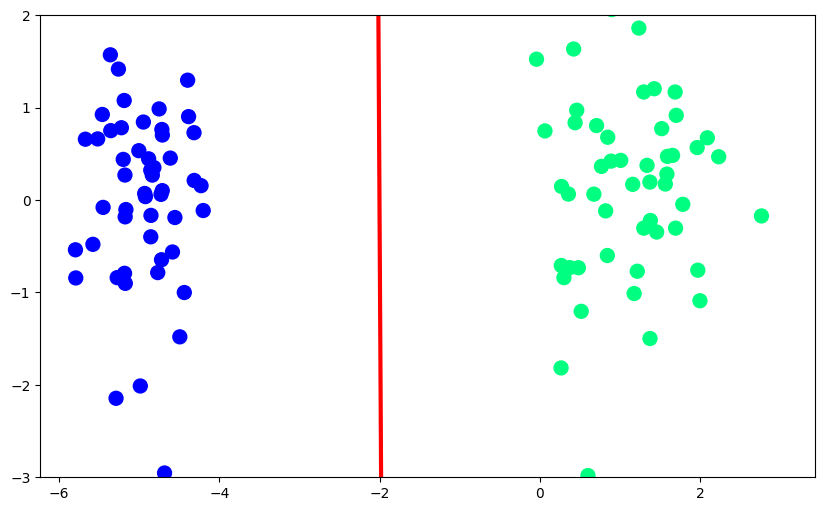

In [18]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

Clearly the sklearn LR model is better than the perceptron trick.

Let's studih the Mathematics involved in the Sklearn method:

Till now we only changed the line on the basis of misclassified points but from now onwards, we will also change the line on the basis of classified points as well.

The points that already lie in the right side/class will now push the line and hence the line will ultimately achieve equilibrium at some point.

**Key Points:**
1. Wrong class → Pull
2. Right class → Push
3. Pull/Push force → Distance from line

`This forms the new model`

In [20]:
# In order to implement all these
# We will use the sigmoid function

### **$$\sigma(z) = \frac{1}{1 + e^{-z}}$$**

z is the dot product of weights and X

Watch video for best understanding but here is the summary:

The sigmoid function basically gives the probability of being in the positive class. The closer to 1, higher the probaility of it being in the positive class.

`0.5 is where the boundary lies`